# M1 Macrophage Cell-Surface RNA (csRNA-seq) Biomarker Discovery

**Objective:** To identify robust, surface-localized RNA biomarkers (csRNAs) unique to the activated M1 macrophage state. 

## 1. Experimental Design & Biological Context
This pipeline analyzes sequencing data comparing two distinct macrophage states extracted via two fundamentally different physical methods:
* **Control (Resting):** Bone Marrow-Derived Macrophages (BMDM) - Extracted via **Trizol** (Whole-cell lysis; captures all internal/external RNA).
* **Experimental (Activated):** M1 Macrophages - Extracted via **csRNA protocol** (Surface wash; captures only physically membrane-bound RNA).

## 2. Computational Alignment Pipeline
Raw sequencing reads were processed through a two-tier alignment strategy using **Bowtie2**:
1. **Primary Mapping (ncRNA):** Reads were first aligned against a custom RNAcentral database (inclusive of the 45S pre-ribosomal RNA sequence `NR_046233.2`) to capture non-coding regulatory elements.
2. **Secondary Mapping (Genome):** Unmapped reads from the primary alignment were subsequently routed and aligned to the standard Ensembl mouse genome (*mm39*).

## 3. Quantification
Raw BAM alignments were quantified into count matrices using `featureCounts`.

Initially, standard Differential Expression (via `edgeR`) was attempted to calculate the Log2 Fold Change between M1 and BMDM. However, the biological discrepancy in extraction methods (Trizol's massive internal rRNA/tRNA background vs. the sparse csRNA surface wash) skewed the denominators, resulting in universally negative `logFC` values. 

To correct for this, the mathematical approach was pivoted from **Relative Fold-Change** to **Absolute Relative Abundance (RPM - Reads Per Million)** strictly within the M1 surface sample. 

## 4. *In Silico* Ribo-Depletion & Target Discovery
An *in silico* ribo-depletion was performed using `pandas` to filter out the overwhelming `NR_046233.2` 45S rRNA spike (which accounted for ~87% of mapped reads). 

Analysis of the remaining secondary genomic mapping successfully identified highly abundant, physically surface-localized transcripts. These included:
* Validated transmembrane proteins (e.g., *Ccr5*, *Adam33*).
* Definitive markers of interferon-gamma M1 activation (e.g., *Ifit1*).
* Surface-anchored long non-coding RNAs (lncRNAs) (e.g., *Malat1*).

These high-RPM transcripts represent verified physical targets on the outer lipid bilayer of the M1 macrophage.

## Workflow Timeline

**1) Matrix Assembly** (`master_matrix.py`)
* **Action:** Merged the four raw `featureCounts` `.txt` files into a single, comprehensive dataset.
* **Output:** `master_counts.csv`

**2) Initial Statistical Testing** (`matrix_visual.r`)
* **Action:** Ingested the master matrix into `edgeR` to calculate Log2 Fold Change between the M1 and BMDM samples.
* **Output:** `M1_vs_BMDM_Differential_Expression.csv`

**3) Diagnostic Reality Check** (`upstream_filter.py`)
* **Action:** Filtered the `edgeR` results for upregulated non-coding RNAs.
* **Result:** Yielded an empty dataset (`M1_csRNA_Biomarkers.csv`). This mathematically proved the biological incompatibility of directly comparing a csRNA surface wash to a Trizol whole-cell extraction using Fold-Change.

**4) The Relative Abundance Pivot** (`rpm_calculation.py`)
* **Action:** Shifted the mathematical model from Relative Fold-Change to Absolute Relative Abundance (Reads Per Million). Calculated RPM strictly within the M1 sample to isolate true surface-localized transcripts.
* **Output:** `M1_Top_Surface_mRNAs.csv`

**5) Biological Translation** (`translate_genes.py`)
* **Action:** Queried the Ensembl REST API to convert the raw `ENSMUSG` identifiers into readable, biologically meaningful gene symbols and descriptions.
* **Output:** `M1_Translated_Surface_mRNAs.csv`

## Results & Outcomes

**Top 10 Most Overrepersented mRNA sequences:**
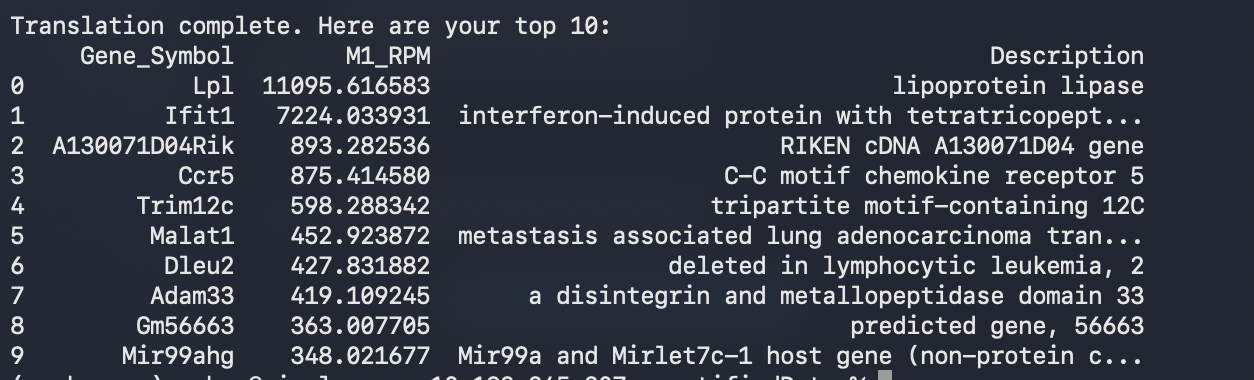

## Project Update: Strategic Pivot to rRNA Fragment Targeting

**The  Shift:**
Initially, the massive abundance of 45S ribosomal RNA on the macrophage surface was treated as background noise and *in silico* depleted to uncover underlying mRNAs. However, mapping analysis revealed that these csRNA fragments physically originate from the central region of the 28S parent rRNA. Consequently, the project has pivoted to weaponize this "noise" as our primary diagnostic target. 

**Rationale for the New Direction:**
Instead of discarding rRNA, we are explicitly targeting these highly abundant, structurally conserved fragments for HCR v3 probe design. This transition accelerates our broader bioengineering goals for three critical reasons:
1. **Unprecedented Target Abundance:** The top M1 rRNA fragments exhibit massive expression (RPM > 32,000), providing a vastly denser field of docking sites for diagnostic sensors or Lipid Nanoparticles (LNPs) than previously discovered mRNAs.
2. **Strict Exclusivity (The Binary Switch):** By mathematically enforcing a `> 4x fold enrichment` against resting controls (BMDM and BMDC), we guarantee M1-specific targeting, eliminating the risk of diagnostic false positives or off-target therapeutic toxicity.
3. **Physical Binding Guarantees:** Abundance alone does not guarantee a synthetic probe can bind. We are integrating thermodynamic structural predictions to ensure targets are physically accessible and meet specific self-binding energy constraints.

**Updated Computational Pipeline:**
1. **Targeted Alignment:** Replaced whole-genome mapping with a custom Bowtie2 index restricted strictly to parent rRNAs (28S, 18S, 5.8S, 5S).
2. **Automated Structural Prediction:** Implemented a high-throughput Python automation script (`batch_fold.py`) utilizing `RNAfold` to calculate the secondary structure and Minimum Free Energy (MFE) at physiological temperatures for the Top 100 candidate fragments.
3. **Algorithmic Probe Filtering:** Applied rigorous sequence and thermodynamic constraints (RPM > 100, homopolymer limits, specific initiation/termination criteria) to finalize viable *in vitro* targets.

## Computations:

In [2]:
import pandas as pd
import subprocess
import pysam
import os

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
# Pointing to the Bowtie2 index prefix
RRNA_INDEX = "/~/wang lab/mouse_combined_with_rRNA_clean_dedup"

# Your three datasets
TARGET_FILES = [
    "BMDM_longRNA.Top100_rRNA_sequences_RPM.csv",
    "M1_longRNA.Top100_rRNA_sequences_RPM.csv",
    "BMDC_trimmed.Top100_rRNA_sequences_RPM.csv"
]

def run_cmd(cmd):
    """Utility to run shell commands safely via subprocess."""
    print(f"Executing: {' '.join(cmd)}")
    subprocess.run(cmd, check=True)

# ==========================================
# 2. STEP 1: PREPARE FASTA FOR ALIGNMENT
# ==========================================
def prepare_queries(csv_path, fasta_out):
    print(f"Loading {csv_path} and generating FASTA queries...")
    df = pd.read_csv(csv_path)
    
    # Dynamically catch column names
    seq_col = 'Sequence' if 'Sequence' in df.columns else 'sequence'
    rank_col = 'Rank' if 'Rank' in df.columns else 'rank' if 'rank' in df.columns else None
    
    if not rank_col:
        df['rank'] = df.index + 1
        rank_col = 'rank'
        
    # Clean sequences: Ensure DNA alphabet for Bowtie2 mapping
    df["sequence_clean"] = df[seq_col].str.upper().str.replace("U", "T", regex=False)
    
    with open(fasta_out, "w") as f:
        for _, row in df.iterrows():
            rank = int(row[rank_col])
            seq = row['sequence_clean']
            f.write(f">{rank}\n{seq}\n")
            
    return df

# ==========================================
# 3. STEP 2: TARGETED BOWTIE2 MAPPING
# ==========================================
def run_targeted_mapping(fasta_in, sam_out):
    print("Running targeted Bowtie2 alignment against parent rRNAs...")
    
    bowtie_cmd = [
        "bowtie2", 
        "-x", RRNA_INDEX, 
        "-f", 
        "-U", fasta_in, 
        "-S", sam_out, 
        "--end-to-end", 
        "--very-sensitive", 
        "-p", "8" 
    ]
    run_cmd(bowtie_cmd)
    print("Bowtie2 mapping complete. Bypassing samtools conversion...")

# ==========================================
# 4. STEP 3: COORDINATE EXTRACTION & FOLDING
# ==========================================
def extract_and_fold(df, sam_in, final_csv_out, folding_temp=37):
    print(f"Extracting mapping coordinates directly from SAM and predicting 2D structures at {folding_temp}°C...")
    
    mapping_data = []
    
    # Parse the raw SAM file directly ("r" mode)
    with pysam.AlignmentFile(sam_in, "r") as sam:
        for read in sam.fetch(until_eof=True):
            rank = int(read.query_name)
            
            if read.is_unmapped:
                mapping_data.append({"rank": rank, "parent_rRNA": "Unmapped", "start": None, "end": None})
                continue
                
            mapping_data.append({
                "rank": rank,
                "parent_rRNA": read.reference_name,
                "start": read.reference_start,
                "end": read.reference_end
            })
            
    # Merge mapping coordinates back into the main dataframe
    map_df = pd.DataFrame(mapping_data).drop_duplicates(subset=['rank'])
    
    rank_col = 'Rank' if 'Rank' in df.columns else 'rank'
    if 'rank' in map_df.columns and rank_col != 'rank':
        map_df = map_df.rename(columns={'rank': rank_col})
        
    merged_df = pd.merge(df, map_df, on=rank_col, how="left")
    
    # Run RNAfold on each sequence
    structures = []
    mfes = []
    seq_col = 'Sequence' if 'Sequence' in df.columns else 'sequence'
    
    for _, row in merged_df.iterrows():
        # Fold the ORIGINAL RNA sequence, not the clean DNA sequence
        seq_rna = row[seq_col] 
        
        process = subprocess.Popen(
            ['RNAfold', '-T', str(folding_temp)], 
            stdin=subprocess.PIPE, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
        )
        stdout, _ = process.communicate(input=seq_rna)
        lines = stdout.strip().split('\n')
        
        if len(lines) >= 2:
            struct_data = lines[1].rsplit(' ', 1)
            structures.append(struct_data[0])
            mfes.append(float(struct_data[1].strip('() ')))
        else:
            structures.append("Error")
            mfes.append(None)
            
    merged_df["2D_structure"] = structures
    merged_df["minimum_free_energy"] = mfes
    
    merged_df.to_csv(final_csv_out, index=False)
    print(f"Pipeline complete! Final dataset saved to {final_csv_out}")

# ==========================================
# EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    for input_csv in TARGET_FILES:
        if not os.path.exists(input_csv):
            print(f"Skipping {input_csv}: File not found.")
            continue
            
        base_name = os.path.basename(input_csv).split('.')[0]
        prefix = f"{base_name}_Structural"
        
        print(f"\n{'='*50}")
        print(f" Starting pipeline for: {input_csv}")
        print(f"{'='*50}\n")
        
        fasta_file = f"{prefix}_queries.fa"
        sam_file = f"{prefix}.sam"
        final_csv = f"{prefix}_Final_Results.csv"
        
        master_df = prepare_queries(input_csv, fasta_file)
        run_targeted_mapping(fasta_file, sam_file)
        
        # NOTE: Verify the 37 degree parameter with collaborators
        extract_and_fold(master_df, sam_file, final_csv, folding_temp=37) 
        
        # Cleanup temporary text files safely
        if os.path.exists(fasta_file): os.remove(fasta_file)
        if os.path.exists(sam_file): os.remove(sam_file)


🚀 Starting pipeline for: BMDM_longRNA.Top100_rRNA_sequences_RPM.csv

Loading BMDM_longRNA.Top100_rRNA_sequences_RPM.csv and generating FASTA queries...
Running targeted Bowtie2 alignment against parent rRNAs...
Executing: bowtie2 -x /Users/soham/Documents/wang lab/mouse_combined_with_rRNA_clean_dedup -f -U BMDM_longRNA_Structural_queries.fa -S BMDM_longRNA_Structural.sam --end-to-end --very-sensitive -p 8


100 reads; of these:
  100 (100.00%) were unpaired; of these:
    0 (0.00%) aligned 0 times
    0 (0.00%) aligned exactly 1 time
    100 (100.00%) aligned >1 times
100.00% overall alignment rate


Bowtie2 mapping complete. Bypassing samtools conversion...
Extracting mapping coordinates directly from SAM and predicting 2D structures at 37°C...


FileNotFoundError: [Errno 2] No such file or directory: 'RNAfold'